In [19]:
#😁p29 넘파이: Numerical Python 산술 계산 라이브러리
# 복잡한 행렬 계산을 하거나, 수치 연산 속도가 극도로 중요할 때
import numpy as np

# 파이썬 리스트 생성
list_data = [1, 2, 3, 4, 5]

# Numpy 배열로 변환
arr = np.array(list_data)

print(f"평균값: {np.mean(arr)}") # 평균 계산
print(f"최댓값: {np.max(arr)}")  # 최댓값 계산
print(f"전체 합: {np.sum(arr)}")  # 합계 계산

# 오류: numpy나 pandas 버전이 서로 맞지 않거나 설치가 깨진 경우
# pip install --upgrade --force-reinstall numpy pandas


# ===========================파이썬버전
# print(f"평균값: {sum(list_data) / len(list_data)}") # sum과 len 조합
# print(f"최댓값: {max(list_data)}")                  # 기본 max 함수
# print(f"전체 합: {sum(list_data)}")                  # 기본 sum 함수

# import pandas as pd #판다스 버전
# s = pd.Series([1, 2, 3, 4, 5])

# print(f"평균값: {s.mean()}")
# print(f"최댓값: {s.max()}")
# print(f"전체 합: {s.sum()}")

평균값: 3.0
최댓값: 5
전체 합: 15


In [ ]:
#🧲번외2️⃣1-2파일로 랜덤수 생성하여 테스트
import pandas as pd
import numpy as np
# 1,000개의 랜덤 정수(1~100 사이) 생성
data = {
    'value': np.random.randint(1, 101, size=1000)
}
# 데이터프레임 생성 및 CSV 저장
df = pd.DataFrame(data)
df.to_csv('random_data.csv', index=False)
print("random_data.csv 파일이 생성되었습니다.")

random_data.csv 파일이 생성되었습니다.


In [ ]:
#🧲번외3️⃣1-3파일로 랜덤수 생성하여 테스트
import pandas as pd
import numpy as np
# 파일 불러오기
df = pd.read_csv('random_data.csv')
# 'value' 열의 데이터를 Numpy 배열로 변환
arr = df['value'].values
# 수치 계산
print(f"데이터 개수: {len(arr)}")
print(f"평균값: {np.mean(arr):.2f}")
print(f"최댓값: {np.max(arr)}")
print(f"전체 합: {np.sum(arr)}")

데이터 개수: 1000
평균값: 49.11
최댓값: 100
전체 합: 49106


In [ ]:
# 😁실무 데이터에는 간혹 말도 안 되게 크거나 작은 값이 섞여 있습니다. 
# Numpy의 조건식을 쓰면 🍋for문 없이 한 줄로 
# 매출 데이터에서 0 이하(오류)나 너무 큰 이상치 제외하기
import numpy as np
sales = np.array([150, 200, -50, 300, 1500, 250]) # -50과 1500이 이상치인 상황
# 3️⃣p138 타입 확인(dtype)과 타입 변환(astype) 
print(f"현재 데이터 타입: {sales.dtype}") #현재 타입 확인 (기본적으로 int64 또는 int32)

# 0보다 크고 1000보다 작은 데이터만 🟢추출 (필터링)
refined_sales = sales[(sales > 0) & (sales < 1000)]
# 2️⃣astype 정제된 데이터를 실수형으로 바꾼 뒤 출력
refined_sales_float = refined_sales.astype(float) 
refined_sales_float
# print(f"정제되기 전: {sales}") #🟢같이 입력해볼 줄
# print(f"정제된 데이터: {refined_sales}")
print(f"변환 후 데이터 타입: {refined_sales_float.dtype}") #2️⃣astype
print(f"정제 후 평균: {np.mean(refined_sales):.1f}") #: 형식을 지정 소수점1자리
print(f"정제 후 평균: {np.mean(refined_sales_float):.1f}")


현재 데이터 타입: int64
변환 후 데이터 타입: float64
정제 후 평균: 225.0
정제 후 평균: 225.0


In [23]:
# 😁데이터 스케일링 (0~1 사이로 맞추기)
# 서로 단위가 다른 데이터(예: 키 180cm vs 몸무게 70kg)를 비교할 때, 
# 모든 데이터를 0에서 1 사이로 맞추는 작업(Min-Max Scaling)이 필수입니다.

# 점수 데이터를 0~1 사이의 상대적 비율로 변환
# 🟢리스트: [1, 2] + [1, 2] → [1, 2, 1, 2] (글자처럼 뒤에 붙어버림) 아래 🍋Cell참조!
# 🟢np.array: np.array([1, 2]) + np.array([1, 2]) → array([2, 4]) (진짜 산술 더하기가 됨)
import numpy as np
scores = np.array([55, 90, 75, 40, 100])

# (현재값 - 최소값) / (최대값 - 최소값)
# 2️⃣ * 100 붙여보기
scaled_scores = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))

print(f"변환된 점수: {scaled_scores}")
# 결과: [0.25, 0.83, 0.58, 0.  , 1.  ] -> 40점은 0, 100점은 1이 됨


변환된 점수: [0.25       0.83333333 0.58333333 0.         1.        ]


In [24]:
# 😁🍋리스트와 np.array 차이
import numpy as np

# 리스트는 계산이 아닌 이어 붙이기가 됨
list_a = [10, 20, 30]
print(list_a * 2)  # [10, 20, 30, 10, 20, 30] 이 나옴 (데이터가 복사됨)

# np.array는 전 성분에 곱하기가 됨 (브로드캐스팅)
arr_a = np.array([10, 20, 30])
print(arr_a * 2)    # [20, 40, 60] (실제 숫자 계산!)


[10, 20, 30, 10, 20, 30]
[20 40 60]


In [ ]:
# 😁🟠np.where를 사용하여 특정 기준(5.0%)에 따라 데이터 분류
import pandas as pd
import numpy as np

# 1. 실무 데이터 생성 (지점별 현재 금리 현황)
data = {
    '지점': ['서울', '부산', '대구', '인천', '광주', '대전'],
    '현재금리': [4.2, 5.8, 3.9, 5.1, 4.8, 6.2]
}
df = pd.DataFrame(data)

# 2. np.where로 조건문 적용 (엑셀의 IF 함수 역할)
# 형식:🔴 np.where(조건, 참일 때 값, 거짓일 때 값)
df['위험도'] = np.where(df['현재금리'] >= 5.0, '고금리(위험)', '정상')

# 3. 결과 확인
print("--- 금리 위험도 분석 결과 ---")
print(df)

# 4. (보너스) 고금리 지점만 🟢따로 추출하기 (필터링)
high_rate_branches = df[df['위험도'] == '고금리(위험)']
print("\n--- 관리 대상 지점 리스트 ---")
print(high_rate_branches)


--- 금리 위험도 분석 결과 ---
   지점  현재금리      위험도
0  서울   4.2       정상
1  부산   5.8  고금리(위험)
2  대구   3.9       정상
3  인천   5.1  고금리(위험)
4  광주   4.8       정상
5  대전   6.2  고금리(위험)

--- 관리 대상 지점 리스트 ---
   지점  현재금리      위험도
1  부산   5.8  고금리(위험)
3  인천   5.1  고금리(위험)
5  대전   6.2  고금리(위험)


In [ ]:
import numpy as np
# 🟢1. 0부터 9까지 10개의 숫자 생성
data = np.arange(10)
print(f"생성된 데이터: {data}")

# 2. 데이터의 개수(모양) 확인
print(f"원래 데이터 모양(shape): {data.shape}") 

# 3. (응용) 모양 바꾸기 (10개를 2행 5열로)
reshaped_data = data.reshape(2, 5)
print("2행 5열로 변신:")
print(reshaped_data)
print(f"새로운 모양: {reshaped_data.shape}")


생성된 데이터: [0 1 2 3 4 5 6 7 8 9]
데이터 모양(shape): (10,)
2행 5열로 변신:
[[0 1 2 3 4]
 [5 6 7 8 9]]
새로운 모양: (2, 5)


In [ ]:
# 🟢1. 클릭 수 확인. 마지막에 5000이라는 '이상치' 포함
click = np.array([250, 300, 280, 320, 5000])
# click.shape #1️⃣데이터수 확인
# 2. 평균 vs 중앙값 비교
print(f"평균 클릭: {np.mean(click)}")   # 약 1230만원 (이상치로 왜곡됨)
print(f"클릭 중앙값 {np.median(click)}") # 300만원 (현실적인 수치)

# 3. 특정 조건 데이터만 추출 (필터링)
# 연봉이 400만원 미만인 '평범한 직장인' 데이터만 뽑기
# click < 400 #🟢2️⃣불리언 이해
normal_click = click[click < 400]
print(f"이상치 제외 데이터: {normal_click}")
# 4. (길이로) 개수 확인
print(f"해당되는 사람 수: {len(normal_click)}명")


(5,)

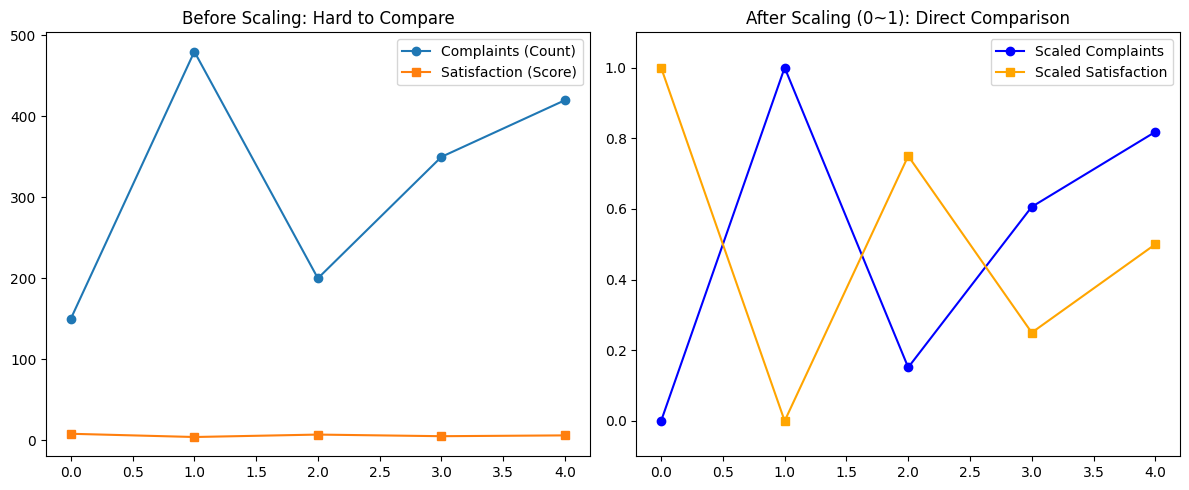

In [46]:
# 서로 단위가 다른(민원건수와 만족도 점수) 데이터를 0과 1 사이의 '점수'로 변환해 비교하는 법"
# 최대-최소 정규화(Min-Max Normalization)' 공식 의미
# 분자 (data - np.min(data)): 데이터에서 최솟값을 빼서, 가장 작은 값을 0으로 만듭니다.
# 분모 (np.max(data) - np.min(data)): 데이터의 전체 범위(최대-최소)로 나누어, 가장 큰 값을 1로 만듭니다.
# 결과: 🟢어떤 숫자든 상관없이 0(최솟값) ~ 1(최댓값) 사이의 비율로 변신합니다.

import numpy as np
import matplotlib.pyplot as plt

# 1. 원본 데이터 생성 (접수 건수와 만족도 점수)
# 접수 건수는 🍋숫자가 크고, 만족도는 🍋숫자가 작습니다.
complaints = np.array([150, 480, 200, 350, 420]) # 민원 건수
satisfaction = np.array([8, 4, 7, 5, 6])          # 만족도 점수

# 2. Min-Max Scaling 🟢함수 적용 // 최대-최소 정규화(Min-Max Normalization)' 공식
def min_max_scale(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

scaled_complaints = min_max_scale(complaints)
scaled_satisfaction = min_max_scale(satisfaction)

# 3. 시각화 비교 (강의용)
plt.figure(figsize=(12, 5))

# [왼쪽] 스케일링 🍋전: 만족도 그래프가 바닥에 붙어서 보이지 않음
plt.subplot(1, 2, 1) #서로 다른 두 그래프를 나란히 배치할 때 [행, 열, 그릴칸]
plt.plot(complaints, label='Complaints (Count)', marker='o')
plt.plot(satisfaction, label='Satisfaction (Score)', marker='s')
plt.title("Before Scaling: Hard to Compare")
plt.legend() #그래프에 '범례(이름표)'를 표시

# [오른쪽] 스케일링 🍋후: 두 지표의 추이를 한눈에 비교 가능
plt.subplot(1, 2, 2)
plt.plot(scaled_complaints, label='Scaled Complaints', marker='o', color='blue')
plt.plot(scaled_satisfaction, label='Scaled Satisfaction', marker='s', color='orange')
plt.title("After Scaling (0~1): Direct Comparison")
plt.ylim(-0.1, 1.1)
plt.legend()

plt.tight_layout() #그래프 간격 여백 최적화
plt.show()

# • 다면 평가 점수 합산: 부서별 인원수가 달라도 비율로 환산하여 공정하게 비교할 때 사용
# • 부서별 예산 집행 효율: 예산 규모가 큰 부서와 작은 부서의 '집행 속도'를 동일 선상에서 비교할 때 필수적
# • 대시보드 구성: 여러 개의 그래프를 하나로 합칠 때, 단위(Unit)를 통일시켜 직관적인 의사결정시 도움

In [47]:
# 👼추가 예제 (시간이 되면)
## [실습 02] Numpy 기초: 부서별 성과 데이터 다루기
### 목표: 넘파이 배열의 구조를 이해하고 고속 연산 체험하기

import numpy as np
# 1. 데이터 생성: 3개 부서의 상반기(1~3월) 성과 지표 (단위: 점)
# 행: 부서(기획팀, 인사팀, IT팀) / 열: 월별 성과(1월, 2월, 3월)
performance = np.array([
    [85, 90, 95], # 기획팀
    [70, 80, 75], # 인사팀
    [90, 85, 80]  # IT팀
])
print("--- 데이터 기본 정보 확인 ---")
print(performance)
# 배열의 모양(shape): "이 데이터가 몇 행 몇 열인지 확인하는 것
# 엑셀 파일의 행/열 개수를 확인하는 것과 같다. 분석 전 가장 먼저 확인.
print(f"배열의 모양(Shape): {performance.shape}")  # (3, 3) -> 3행 3열
print(f"차원 수(Dimension): {performance.ndim}차원")
print(f"데이터 타입(dtype): {performance.dtype}")


# 모든 부서의 성과에 '가산점 5점'을 🍋일괄 부여해야 한다면?
# 엑셀: 모든 셀에 +5 수식 입력 / 넘파이: 그냥 +5
# 🟢브로드캐스팅: "수천 개의 셀에 일일이 더하기 수식을 복사할 필요가 없이
#  넘파이는 숫자 하나만 더해도 모든 칸에 알아서 적용해 줌.
plus_five = performance + 5
print("\n--- 가산점 +5점 반영 결과 ---")
print(plus_five)
# 성과 지표를 100점 만점 기준의 '비율(0~1)'로 변환
ratio = performance / 100
print("\n--- 백분율 변환 결과 ---")
print(ratio)

# 전체 부서의 평균 점수
total_avg = np.mean(performance)

# 부서별(행 단위) 평균 점수 계산 (axis=1) //0은 세로(월별), 1은 가로(부서별)
dept_avg = np.mean(performance, axis=1)

# 월별(열 단위) 최고 점수 계산 (axis=0)
monthly_max = np.max(plus_five, axis=0) # plus_five 대신 performance

print(f"\n전체 평균: {total_avg:.2f}")
print(f"부서별 평균: {dept_avg}")
print(f"월별 최고점: {monthly_max}")

--- 데이터 기본 정보 확인 ---
[[85 90 95]
 [70 80 75]
 [90 85 80]]
배열의 모양(Shape): (3, 3)
차원 수(Dimension): 2차원
데이터 타입(dtype): int64

--- 가산점 +5점 반영 결과 ---
[[ 90  95 100]
 [ 75  85  80]
 [ 95  90  85]]

--- 백분율 변환 결과 ---
[[0.85 0.9  0.95]
 [0.7  0.8  0.75]
 [0.9  0.85 0.8 ]]

전체 평균: 83.33
부서별 평균: [90. 75. 85.]
월별 최고점: [ 95  95 100]
